Research question 

To what extent are municipalities able to achieve “green growth” (or post-growth?) in British Columbia, as measured by a decoupling of growth in wellbeing from the growth in transportation and utility GHG emissions? 

What inequities exist in the access of solar energy across B.C.? Do these inequities correlate with lower housing wellbeing index?

Scope 

Timeframe: 2012 – 2021 

Emissions scope: CO2e for utilities of residential and small and medium indistry, on-road transportation

In [1]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [2]:
#load the community emissions dataset as csv file
utility_emissions = pd.read_csv('../data/raw/utilities_new.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2022.0,BC Hydro,11080.0,5909052.0,Abbotsford,1005909.0,ELEC,kWh,Res,538127235.5,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022.0,BC Hydro,11080.0,1005923.0,Alberni-Clayoquot,9000000.0,ELEC,kWh,Res,226116610.6,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022.0,BC Hydro,11080.0,2005923.0,Alberni-Clayoquot Unincorporated Areas,1005923.0,ELEC,kWh,Res,79348847.45,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022.0,BC Hydro,11080.0,5943008.0,Alert Bay,1005943.0,ELEC,kWh,Res,3775260.192,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022.0,BC Hydro,11080.0,5915038.0,Anmore,1005915.0,ELEC,kWh,Res,14323873.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12994/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


To add industrial emissions:
1. convert lat and lon of each industry to points that can fall within the area of the municipal boundaries
2. assign the municipality name to each industry in the industries dataset (creating a new column to hold the municipality names in the industry dataset)
3. sum up the emissions of all industries within each municipality area and assign total emissions to that municipality in a new dataset
4. change the naming of municipalities in the shape file to match the naming of the other emissions datasets, so that we can aggregate these emissions

In [4]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Northern Rockies Unincorporated Areas", #check if there are variations to this, like Northern Rockies Regional Municipality Unincorporated Areas
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)"]
 
outliers = ["Northern Rockies Regional Municipality","Northern Rockies RD", "Northern Rockies"]

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [5]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
utility_df = utility_emissions[mask]
print(utility_df['ORG_NAME'].unique())
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_utility_emissions.csv'), index=False)
utility_df.head()

['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Central Saanich' 'Chase' 'Chetwynd'
 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood' 'Comox'
 'Coquitlam' 'Courtenay' 'Cranbrook' 'Cumberland' 'Dawson Creek' 'Delta'
 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie' 'Fort St. James'
 'Fort St. John' 'Fraser Lake' 'Gibsons' 'Gold River' 'Golden' 'Granisle'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kelowna' 'Kent' 'Kimberley'
 'Kitimat' 'Ladysmith' 'Lake Country' 'Lake Cowichan' 'Langford'
 'Langley City' 'Langley Township' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Mission' 'Nakusp' 'Nanaimo' 'New Denver'
 'New Hazelton' 'North Cowichan' 'North Saanich' 'North Vancouver City'
 'North Vancouver District' 'Nort

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2022.0,BC Hydro,11080.0,5909052.0,Abbotsford,1005909.0,ELEC,kWh,Res,538127235.5,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022.0,BC Hydro,11080.0,5943008.0,Alert Bay,1005943.0,ELEC,kWh,Res,3775260.192,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022.0,BC Hydro,11080.0,5915038.0,Anmore,1005915.0,ELEC,kWh,Res,14323873.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022.0,BC Hydro,11080.0,5937028.0,Armstrong,1005937.0,ELEC,kWh,Res,21935314.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022.0,BC Hydro,11080.0,5933019.0,Ashcroft,1005933.0,ELEC,kWh,Res,7649213.599,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#select municipalities from the transportation emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt",
    "Sechelt Ind Gov Dist (Part-Powell River)": "Sechelt IGD",
    "Sechelt Ind Gov Dist": "Sechelt IGD"
})
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_transportation_emissions.csv'), index=False)
transportation_df.head()
#print(transportation_df['ORG_NAME'].unique())

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12994/2368270769.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
5,5915025,Burnaby,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,9.62,112885.828400,56668.685860,77.069859,NaN


In [7]:

# Remove commas from the values, then convert to numeric
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

#correct norther rockies to northern rockies
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Norther Rockies Regional Municipality', 'Northern Rockies Regional Municipality')

# Add emissions for "Northern Rockies" and "Northern Rockies Regional Municipality"
print("Before combining:")
northern_rockies_data = utility_df[
    utility_df['ORG_NAME'].str.contains('northern rockies', case=False, na=False)
]
print(northern_rockies_data)

# Replace the name first, then group and sum
total_utility_emissions_combined = utility_df.copy()

# Replace "Northern Rockies Regional Municipality" with "Northern Rockies"
total_utility_emissions_combined['ORG_NAME'] = total_utility_emissions_combined['ORG_NAME'].replace(
    'Northern Rockies Regional Municipality', 'Northern Rockies'
)

# Group by YEAR and ORG_NAME, summing the emissions
total_utility_emissions_combined = total_utility_emissions_combined.groupby(
    ['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()


print("\nAfter combining:")
northern_rockies_combined = total_utility_emissions_combined[
    total_utility_emissions_combined['ORG_NAME'].str.contains('northern rockies', case=False, na=False)
]
print(northern_rockies_combined)

total_utility_emissions = total_utility_emissions_combined

#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)
total_utility_emissions.tail()


Before combining:
         YEAR            SOURCE  Data Source ID   ORG_UNIT  \
116    2022.0          BC Hydro         11080.0  5959816.0   
313    2022.0          BC Hydro         11080.0  5959816.0   
511    2022.0          BC Hydro         11080.0  5959816.0   
708    2021.0          BC Hydro         10080.0  5959816.0   
905    2021.0          BC Hydro         10080.0  5959816.0   
...       ...               ...             ...        ...   
19760  2012.0  Estimate-Propane         11190.0  5959007.0   
19790  2010.0  Estimate-Propane         11190.0  1005959.0   
19979  2010.0  Estimate-Propane         11190.0  5959007.0   
20009  2007.0  Estimate-Propane         11190.0  1005959.0   
20198  2007.0  Estimate-Propane         11190.0  5959007.0   

                                     ORG_NAME   ORG_PART ENERGY_TYPE  \
116    Northern Rockies Regional Municipality  1005959.0        ELEC   
313    Northern Rockies Regional Municipality  1005959.0        ELEC   
511    Northern Rocki

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12994/2160989905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_12994/2160989905.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)
/

,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e)
2088,2022.0,West Vancouver,135173.833942
2089,2022.0,Whistler,57678.669702
2090,2022.0,White Rock,42636.687571
2091,2022.0,Williams Lake,86472.003657
2092,2022.0,Zeballos,151.410986


In [8]:
#print all unique org-names in the utilties dataframe
print("Unique organizations in utility emissions:")
print(total_utility_emissions['ORG_NAME'].unique())

Unique organizations in utility emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Mon

In [9]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
        YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0     2007.0      Abbotsford                  369133.300024
1     2007.0       Alert Bay                     835.510099
2     2007.0          Anmore                    4442.247271
3     2007.0       Armstrong                   11999.055741
4     2007.0        Ashcroft                   14440.813090
...      ...             ...                            ...
2088  2022.0  West Vancouver                  135173.833942
2089  2022.0        Whistler                   57678.669702
2090  2022.0      White Rock                   42636.687571
2091  2022.0   Williams Lake                   86472.003657
2092  2022.0        Zeballos                     151.410986

[2093 rows x 3 columns]


In [10]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_df.groupby(['Year', 'ORG_NAME'])['Emissions tCO2e'].sum().reset_index()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [11]:
print("Unique organizations in total_emissions:")
print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Montr

In [12]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
print(total_transportation_emissions)


Total transportation emissions for each community:
      Year        ORG_NAME  Emissions tCO2e
0     2007      Abbotsford    466925.103045
1     2007       Alert Bay      1022.397977
2     2007          Anmore      5836.238127
3     2007       Armstrong     21883.647495
4     2007        Ashcroft      7518.235865
...    ...             ...              ...
2571  2022  West Vancouver     87183.024487
2572  2022        Whistler     45378.848302
2573  2022      White Rock     50525.617995
2574  2022   Williams Lake     65210.910339
2575  2022        Zeballos       323.540670

[2576 rows x 3 columns]


In [13]:
print ("\nTotal utility emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
print(total_utility_emissions)


Total utility emissions for each community:
        YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0     2007.0      Abbotsford                  369133.300024
1     2007.0       Alert Bay                     835.510099
2     2007.0          Anmore                    4442.247271
3     2007.0       Armstrong                   11999.055741
4     2007.0        Ashcroft                   14440.813090
...      ...             ...                            ...
2088  2022.0  West Vancouver                  135173.833942
2089  2022.0        Whistler                   57678.669702
2090  2022.0      White Rock                   42636.687571
2091  2022.0   Williams Lake                   86472.003657
2092  2022.0        Zeballos                     151.410986

[2093 rows x 3 columns]


In [14]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)
# Find communities that are in utility emissions but not in transportation emissions
missing_communities = utility_emissions_communities_list - transportation_emissions_communities_list
print("\nCommunities in utility emissions but not in transportation emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()

Communities in utility emissions but not in transportation emissions:
set()


In [15]:
total_transportation_emissions.rename(columns={'Year': 'YEAR'}, inplace=True)


In [16]:
transportation_emissions_pivot = total_transportation_emissions.pivot(index='ORG_NAME', columns='YEAR', values='Emissions tCO2e')

utility_emissions_pivot = total_utility_emissions.pivot(index='ORG_NAME', columns='YEAR', values='EMISSIONS NET IMPORTS (TCO2e)')


In [17]:
test_utility_emissions_pivot = total_utility_emissions.pivot(index='SUB_SECTOR', columns='YEAR', values='EMISSIONS NET IMPORTS (TCO2e)')


KeyError: 'SUB_SECTOR'

In [ ]:
utility_emissions_pivot.head()

YEAR,2007.0,2010.0,2012.0,2013.0,2014.0,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0
ORG_NAME,,,,,,,,,,,,,
Abbotsford,369133.300024,341601.814527,372688.520620,365256.374210,348246.095310,328809.755914,356918.007350,402045.249005,389259.357606,411629.390389,431473.117780,438694.200759,454597.561346
Alert Bay,835.510099,533.831270,489.178580,478.787934,447.917669,394.335894,407.920965,388.503609,341.014694,328.932993,313.657185,306.754256,306.167039
Anmore,4442.247271,4255.111461,4826.869437,4709.853809,4576.729250,4166.447087,4551.117951,5362.867480,4913.003227,5186.380978,5587.591984,5680.226281,5533.299813
Armstrong,11999.055741,11304.114372,11741.103445,11471.638247,11390.752211,9878.661491,10115.208817,12299.461948,11598.364017,11923.081131,11555.087269,11937.765940,13125.116057
Ashcroft,14440.813090,11896.684593,12502.156186,12858.399424,12648.567683,12317.773854,12334.160649,13492.548923,13075.766701,13121.302369,13123.561100,11471.000930,10911.427065


In [ ]:
transportation_emissions_pivot.head()

YEAR,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
ORG_NAME,,,,,,,,,,,,,,,,
Abbotsford,466925.103045,474459.952073,479387.196167,485110.482874,493169.569935,503601.363016,505910.381646,517010.028841,534121.936848,569263.582000,571756.692144,594002.984836,601000.827899,554032.496719,607226.864111,575051.027075
Alert Bay,1022.397977,1019.378791,1025.923233,1037.388946,1054.170924,1059.040405,1144.279362,1165.906857,1174.273646,1194.705601,1187.471740,1270.422623,1151.323188,1036.310827,964.113268,992.900932
Anmore,5836.238127,6169.357649,6474.856377,6773.468238,7066.984538,7107.155106,7195.800893,7338.996866,7252.107619,7421.111512,7236.320095,7702.921363,7265.602075,6586.514833,5665.476953,5999.985251
Armstrong,21883.647495,22410.183713,23245.464128,24025.957496,24738.884005,25401.554630,26989.066259,25920.824520,27487.084136,26823.412983,25651.711947,22562.323800,22355.080141,19990.918666,22235.237768,24356.948696
Ashcroft,7518.235865,7631.096096,7855.899555,8066.437422,8261.180993,8434.749383,6357.733814,7630.838747,7670.597061,6743.397754,6808.900764,7236.693618,7050.801774,6321.059886,7521.356238,8026.311419


In [ ]:
# Create the relative emissions DataFrame
# This divides every value in each row by that row's 2007 value.
relative_utility_emissions = utility_emissions_pivot.div(utility_emissions_pivot[2007], axis=0)
relative_transportation_emissions = transportation_emissions_pivot.div(transportation_emissions_pivot[2007], axis=0)
# Let's look at the result
print("Relative utility emissions \n", relative_utility_emissions.head(), "\n" )
print("Relative transportation emissions \n", relative_transportation_emissions.head())

Relative utility emissions 
 YEAR        2007.0    2010.0    2012.0    2013.0    2014.0    2015.0  \
ORG_NAME                                                               
Abbotsford     1.0  0.925416  1.009631  0.989497  0.943416  0.890762   
Alert Bay      1.0  0.638929  0.585485  0.573049  0.536101  0.471970   
Anmore         1.0  0.957874  1.086583  1.060241  1.030273  0.937914   
Armstrong      1.0  0.942084  0.978502  0.956045  0.949304  0.823287   
Ashcroft       1.0  0.823824  0.865752  0.890421  0.875890  0.852983   

YEAR          2016.0    2017.0    2018.0    2019.0    2020.0    2021.0  \
ORG_NAME                                                                 
Abbotsford  0.966908  1.089160  1.054522  1.115124  1.168882  1.188444   
Alert Bay   0.488230  0.464990  0.408151  0.393691  0.375408  0.367146   
Anmore      1.024508  1.207242  1.105972  1.167513  1.257830  1.278683   
Armstrong   0.843000  1.025036  0.966606  0.993668  0.963000  0.994892   
Ashcroft    0.854118  

In [ ]:
relative_utility_emissions.index.values
#this shows that northern rockies has two entries: ['Northern Rockies', 'Northern Rockies Regional Municipality']

array(['Abbotsford', 'Alert Bay', 'Anmore', 'Armstrong', 'Ashcroft',
       'Barriere', 'Belcarra', 'Bowen Island', 'Burnaby', 'Burns Lake',
       'Cache Creek', 'Campbell River', 'Canal Flats', 'Castlegar',
       'Central Saanich', 'Chase', 'Chetwynd', 'Chilliwack', 'Clearwater',
       'Clinton', 'Coldstream', 'Colwood', 'Comox', 'Coquitlam',
       'Courtenay', 'Cranbrook', 'Creston', 'Cumberland', 'Dawson Creek',
       'Delta', 'Duncan', 'Elkford', 'Enderby', 'Esquimalt', 'Fernie',
       'Fort St. James', 'Fort St. John', 'Fraser Lake', 'Fruitvale',
       'Gibsons', 'Gold River', 'Golden', 'Grand Forks', 'Granisle',
       'Greenwood', 'Harrison Hot Springs', 'Hazelton', 'Highlands',
       'Hope', 'Houston', "Hudson's Hope", 'Invermere', 'Kamloops',
       'Kaslo', 'Kelowna', 'Kent', 'Keremeos', 'Kimberley', 'Kitimat',
       'Ladysmith', 'Lake Country', 'Lake Cowichan', 'Langford',
       'Langley City', 'Langley Township', 'Lantzville', 'Lillooet',
       'Lions Bay', 'Loga

In [ ]:
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
cwb_2006 = pd.read_csv(os.path.join('..','data','raw','CWB_2006.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

print("\n CWB_2006_dataset:")
print(cwb_2006.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [ ]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915046, 'CSD Name 2011'] = 'North Vancouver District'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915051, 'CSD Name 2011'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915046, 'CSD Name 2006'] = 'North Vancouver District'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915051, 'CSD Name 2006'] = 'North Vancouver City'


#rename sun peaks mountain to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2011['CSD Name 2011'] = cwb_2011['CSD Name 2011'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2006['CSD Name 2006'] = cwb_2006['CSD Name 2006'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915001, 'CSD Name 2011'] = 'Langley Township'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915001, 'CSD Name 2006'] = 'Langley Township'


#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915002, 'CSD Name 2011'] = 'Langley City'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915002, 'CSD Name 2006'] = 'Langley City'


# Replace Sechelt (Part) entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5929803, 'CSD Name 2021'] = 'Sechelt IGD'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5929803, 'CSD Name 2016'] = 'Sechelt IGD'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5929803, 'CSD Name 2011'] = 'Sechelt IGD'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5929803, 'CSD Name 2006'] = 'Sechelt IGD'

#rename CSD Name / Nom de la SDR 2006 to CSD Name 2006
cwb_2006.rename(columns={'CSD Name 2006': 'CSD Name 2006'}, inplace=True)
#rename CSD Code / Code de la SDR 2006 to CSD Code 2006
cwb_2006.rename(columns={'CSD Code SDR 2006': 'CSD Code 2006'}, inplace=True)  

In [ ]:
#remove cities with the same name in the wellbeing dataset that are not from BC

# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008,
    'Langford' : 5917044,
}

# Remove duplicates by keeping only the BC CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

# Remove duplicates from 2011 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2011 = cwb_2011[~((cwb_2011['CSD Name 2011'] == city_name) & 
                          (cwb_2011['CSD Code 2011'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

# Remove duplicates from 2006 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2006 = cwb_2006[~((cwb_2006['CSD Name 2006'] == city_name) & 
                          (cwb_2006['CSD Code 2006'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset
Removed duplicate cities from 2006 dataset
Removed duplicate cities from 2006 dataset


In [ ]:
# Get unique community names from each dataset as a list
transportation_emissions_communities = set(relative_transportation_emissions.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())
wellbeing_2011_communities = set(cwb_2011['CSD Name 2011'].dropna())
wellbeing_2006_communities = set(cwb_2006['CSD Name 2006'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = transportation_emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = transportation_emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_2011 = transportation_emissions_communities.intersection(wellbeing_2011_communities)
exact_matches_2006 = transportation_emissions_communities.intersection(wellbeing_2006_communities)
exact_matches_2021_2016_2011 = exact_matches_2021.intersection(exact_matches_2016).intersection(exact_matches_2011)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with 2011 wellbeing: {len(exact_matches_2011)}")
print(f"Exact matches with 2006 wellbeing: {len(exact_matches_2006)}")
print(f"Exact matches with 2021, 2016, and 2011 wellbeing: {len(exact_matches_2021_2016_2011)}")
#print(f"Exact matches with both years: {len(exact_matches_both)}")

# Get unmatched communities by subtracting lists
unmatched_emissions = transportation_emissions_communities - exact_matches_2006

print(f"Total unmatched emissions communities: {len(unmatched_emissions)}")
print("\nAll unmatched emissions communities:")
for community in sorted(list(unmatched_emissions)):
    print(f"  {community}")

Exact matches with 2021 wellbeing: 161
Exact matches with 2016 wellbeing: 161
Exact matches with 2011 wellbeing: 161
Exact matches with 2006 wellbeing: 156
Exact matches with 2021, 2016, and 2011 wellbeing: 161
Total unmatched emissions communities: 5

All unmatched emissions communities:
  Barriere
  Clearwater
  Northern Rockies
  Sun Peaks Mountain Resort
  West Kelowna


In [ ]:
print(transportation_emissions_communities) #these unmatched communities are all in the transportation emissions dataset, so maybe not in the wellbeing dataset

{'Langley Township', 'Qualicum Beach', 'Greenwood', 'Houston', 'West Vancouver', 'Kelowna', 'Nakusp', 'Comox', 'Campbell River', 'Bowen Island', 'Oak Bay', 'Kamloops', 'Whistler', 'Ladysmith', 'Langley City', 'Port Alberni', 'Quesnel', 'Creston', 'Tahsis', 'Fruitvale', 'Princeton', 'Courtenay', 'Zeballos', 'New Hazelton', 'Highlands', 'Castlegar', 'Canal Flats', 'Silverton', "Hudson's Hope", 'Rossland', 'Armstrong', 'Burnaby', 'Hope', 'Port Edward', 'Penticton', 'Sechelt', 'Port Hardy', 'Terrace', 'Tumbler Ridge', 'Elkford', 'Chetwynd', 'Dawson Creek', 'Ashcroft', 'Lytton', 'Alert Bay', 'Kent', 'Keremeos', 'Trail', 'North Cowichan', 'Sechelt IGD', 'Kimberley', 'View Royal', 'Radium Hot Springs', 'Kaslo', 'Valemount', 'Metchosin', 'Sun Peaks Mountain Resort', 'Vernon', 'Smithers', 'Belcarra', 'Barriere', 'New Denver', 'Queen Charlotte', 'Clinton', 'Telkwa', 'Duncan', 'Sparwood', 'Colwood', 'Fort St. James', 'Merritt', 'Sicamous', 'Montrose', 'Parksville', 'Chilliwack', 'Squamish', 'Lang

In [ ]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2011 = cwb_2011[cwb_2011['CSD Name 2011'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2006 = cwb_2006[cwb_2006['CSD Name 2006'].isin(exact_matches_2021_2016_2011)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")
print(f"  2011: {len(matched_cwb_2011)} communities")
print(f"  2006: {len(matched_cwb_2006)} communities")   

# Also filter emissions data to matched communities
matched_transportation_emissions = relative_transportation_emissions[relative_transportation_emissions.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Transportation Emissions: {len(matched_transportation_emissions)} communities")

# Also filter emissions data to matched communities
matched_utility_emissions = relative_utility_emissions[relative_utility_emissions.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Utility Emissions: {len(matched_utility_emissions)} communities")

Filtered wellbeing data:
  2021: 161 communities
  2016: 161 communities
  2011: 161 communities
  2006: 156 communities
  Transportation Emissions: 161 communities
  Utility Emissions: 161 communities


In [ ]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
print(duplicates_2011)

print("\nDuplicate community names in 2006 wellbeing data:")
duplicates_2006 = matched_cwb_2006[cwb_2006.duplicated('CSD Name 2006', keep=False)]['CSD Name 2006'].value_counts()
print(duplicates_2006)


Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2006 wellbeing data:
Series([], Name: count, dtype: int64)


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_83041/301006080.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_83041/301006080.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_83041/301006080.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_83041/301006080.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_

In [ ]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)
matched_cwb_2011.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2011.csv'), index=False)
matched_cwb_2006.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2006.csv'), index=False)   

In [ ]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2006_clean = matched_cwb_2006[['CSD Name 2006', 'CWB 2006', 'Income 2006', 'Education 2006', 'Housing 2006', 'Labour Force Activity 2006','Census Population 2006']].copy()
wellbeing_2011_clean = matched_cwb_2011[['CSD Name 2011', 'CWB 2011', 'Income 2011', 'Education 2011', 'Housing 2011', 'Labour Force Activity 2011','Census Population 2011']].copy()
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2006_clean = wellbeing_2006_clean.rename(columns={'CSD Name 2006': 'Municipality_Name'})
wellbeing_2011_clean = wellbeing_2011_clean.rename(columns={'CSD Name 2011': 'Municipality_Name'})
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Municipality_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Municipality_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2021_clean, wellbeing_2016_clean, on='Municipality_Name', how='inner')
wellbeing_combined = pd.merge(wellbeing_combined, wellbeing_2011_clean, on='Municipality_Name', how='inner')
wellbeing_combined_2006 = pd.merge(wellbeing_combined, wellbeing_2006_clean, on='Municipality_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined)} communities")


Wellbeing data merged: 161 communities


In [ ]:
print(wellbeing_combined)

    Municipality_Name  CWB 2021  Income 2021  Education 2021  Housing 2021  \
0             Elkford      85.0         87.0            66.0          97.0   
1            Sparwood      84.0         86.0            63.0          97.0   
2              Fernie      86.0         86.0            74.0          94.0   
3           Cranbrook      82.0         80.0            64.0          96.0   
4           Kimberley      83.0         80.0            70.0          95.0   
..                ...       ...          ...             ...           ...   
156      Dawson Creek      80.0         81.0            59.0          93.0   
157     Hudson's Hope      81.0         82.0            58.0          95.0   
158            Taylor      79.0         82.0            56.0          94.0   
159     Fort St. John      82.0         84.0            63.0          94.0   
160  Northern Rockies      80.0         82.0            58.0          95.0   

     Labour Force Activity 2021  Census Population 2021  CWB 20

In [ ]:
# Calculate wellbeing changes
wellbeing_combined['cwb_percent_change'] = ((wellbeing_combined['CWB 2021'] - wellbeing_combined['CWB 2011']) / wellbeing_combined['CWB 2011'] * 100)
wellbeing_combined['income_percent_change'] = ((wellbeing_combined['Income 2021'] - wellbeing_combined['Income 2011']) / wellbeing_combined['Income 2011'] * 100)
wellbeing_combined['education_percent_change'] = ((wellbeing_combined['Education 2021'] - wellbeing_combined['Education 2011']) / wellbeing_combined['Education 2011'] * 100)
wellbeing_combined['housing_percent_change'] = ((wellbeing_combined['Housing 2021'] - wellbeing_combined['Housing 2011']) / wellbeing_combined['Housing 2011'] * 100)
wellbeing_combined['labour_percent_change'] = ((wellbeing_combined['Labour Force Activity 2021'] - wellbeing_combined['Labour Force Activity 2011']) / wellbeing_combined['Labour Force Activity 2011'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [181]:
#there are no utility emissions for 2008, 2009 or 2011, only for 2007 and 2010, so we will calculate the percent change between 2007-2010 and 2017-2020

# Step 1: Calculate mean emissions between 2007-2010 for each municipality
utility_emissions_2007_2010 = total_utility_emissions[
    (total_utility_emissions['YEAR'] == 2007) |
    (total_utility_emissions['YEAR'] == 2010)
].groupby('ORG_NAME')['EMISSIONS NET IMPORTS (TCO2e)'].mean().reset_index()
utility_emissions_2007_2010.columns = ['Municipality_Name', 'avg_utility_emissions_2007_2010']

# Step 2: Calculate mean emissions between 2017-2020 for each municipality
utility_emissions_2017_2020 = total_utility_emissions[
    (total_utility_emissions['YEAR'] >= 2017) &
    (total_utility_emissions['YEAR'] <= 2020)
].groupby('ORG_NAME')['EMISSIONS NET IMPORTS (TCO2e)'].mean().reset_index()
utility_emissions_2017_2020.columns = ['Municipality_Name', 'avg_utility_emissions_2017_2020']

# Step 3: Merge the two periods and calculate percent change
utility_emissions_change = pd.merge(utility_emissions_2007_2010, utility_emissions_2017_2020, 
                           on='Municipality_Name', how='outer')

# Calculate percent change: ((new - old) / old) * 100
utility_emissions_change['utility_emissions_percent_change'] = (
    (utility_emissions_change['avg_utility_emissions_2017_2020'] - utility_emissions_change['avg_utility_emissions_2007_2010']) / 
    utility_emissions_change['avg_utility_emissions_2007_2010']
) * 100

# Optional: Handle cases where 2007-2010 data is 0 or missing
utility_emissions_change['utility_emissions_percent_change'] = utility_emissions_change['utility_emissions_percent_change'].replace(
    [np.inf, -np.inf], np.nan
)

print("Emissions change summary:")
print(utility_emissions_change.head())
print(f"\nDataset shape: {utility_emissions_change.shape}")
print(f"Municipalities with data for both periods: {utility_emissions_change.dropna().shape[0]}")

# Step 4: Merge with wellbeing dataset
final_analysis_data = pd.merge(utility_emissions_change, wellbeing_combined, 
                              on='Municipality_Name', how='inner')

print(f"\nFinal merged dataset shape: {final_analysis_data.shape}")
print("\nFinal dataset columns:")
print(final_analysis_data.columns.tolist())

# Optional: Display some summary statistics
print("\nUtility emissions change statistics:")
print(final_analysis_data['utility_emissions_percent_change'].describe())

Emissions change summary:
  Municipality_Name  avg_utility_emissions_2007_2010  \
0        Abbotsford                    355367.557275   
1         Alert Bay                       684.670685   
2            Anmore                      4348.679366   
3         Armstrong                     11651.585057   
4          Ashcroft                     13168.748841   

   avg_utility_emissions_2017_2020  utility_emissions_percent_change  
0                    408601.778695                         14.980045  
1                       343.027120                        -49.898962  
2                      5262.460917                         21.012852  
3                     11843.998591                          1.651394  
4                     13203.294773                          0.262333  

Dataset shape: (161, 4)
Municipalities with data for both periods: 161

Final merged dataset shape: (161, 27)

Final dataset columns:
['Municipality_Name', 'avg_utility_emissions_2007_2010', 'avg_utility_emissi

In [182]:
# Step 1: Calculate mean emissions between 2007-2010 for each municipality
transportation_emissions_2007_2010 = total_transportation_emissions[
    (total_transportation_emissions['YEAR'] == 2007) |
    (total_transportation_emissions['YEAR'] == 2010)
].groupby('ORG_NAME')['Emissions tCO2e'].mean().reset_index()
transportation_emissions_2007_2010.columns = ['Municipality_Name', 'avg_transportation_emissions_2007_2010']

# Step 2: Calculate mean emissions between 2017-2020 for each municipality
transportation_emissions_2017_2020 = total_transportation_emissions[
    (total_transportation_emissions['YEAR'] >= 2017) &
    (total_transportation_emissions['YEAR'] <= 2020)
].groupby('ORG_NAME')['Emissions tCO2e'].mean().reset_index()
transportation_emissions_2017_2020.columns = ['Municipality_Name', 'avg_transportation_emissions_2017_2020']

# Step 3: Merge the two periods and calculate percent change
transportation_emissions_change = pd.merge(transportation_emissions_2007_2010, transportation_emissions_2017_2020, 
                           on='Municipality_Name', how='outer')

# Calculate percent change: ((new - old) / old) * 100
transportation_emissions_change['transportation_emissions_percent_change'] = (
    (transportation_emissions_change['avg_transportation_emissions_2017_2020'] - transportation_emissions_change['avg_transportation_emissions_2007_2010']) / 
    transportation_emissions_change['avg_transportation_emissions_2007_2010']
) * 100

# Optional: Handle cases where 2007-2010 data is 0 or missing
transportation_emissions_change['transportation_emissions_percent_change'] = transportation_emissions_change['transportation_emissions_percent_change'].replace(
    [np.inf, -np.inf], np.nan
)

print("Emissions change summary:")
print(transportation_emissions_change.head())
print(f"\nDataset shape: {transportation_emissions_change.shape}")
print(f"Municipalities with data for both periods: {transportation_emissions_change.dropna().shape[0]}")

# Step 4: Merge with wellbeing dataset
final_analysis_data = pd.merge(transportation_emissions_change, final_analysis_data, 
                              on='Municipality_Name', how='inner')

print(f"\nFinal merged dataset shape: {final_analysis_data.shape}")
print("\nFinal dataset columns:")
print(final_analysis_data.columns.tolist())

# Optional: Display some summary statistics
print("\nEmissions change statistics:")
print(final_analysis_data['transportation_emissions_percent_change'].describe())

Emissions change summary:
  Municipality_Name  avg_transportation_emissions_2007_2010  \
0        Abbotsford                           476017.792959   
1         Alert Bay                             1029.893462   
2            Anmore                             6304.853183   
3         Armstrong                            22954.802496   
4          Ashcroft                             7792.336643   

   avg_transportation_emissions_2017_2020  \
0                           580198.250399   
1                             1161.382094   
2                             7197.839592   
3                            22640.008639   
4                             6854.364010   

   transportation_emissions_percent_change  
0                                21.885833  
1                                12.767207  
2                                14.163477  
3                                -1.371364  
4                               -12.037116  

Dataset shape: (161, 4)
Municipalities with data for 

In [183]:
# Calculate per capita emissions
#final_analysis_data['2012_total_emissions_per_capita'] = final_analysis_data['2012 total emissions tCO2e'] / final_analysis_data['Census Population 2011']
#final_analysis_data['2021_total_emissions_per_capita'] = final_analysis_data['2021 total emissions tCO2e'] / final_analysis_data['Census Population 2021']
#final_analysis_data['total_emissions_per_capita_change'] = ((final_analysis_data['2021_total_emissions_per_capita'] - final_analysis_data['2012_total_emissions_per_capita']) / final_analysis_data['2012_total_emissions_per_capita'] * 100)
final_analysis_data['population_percent_change'] = ((final_analysis_data['Census Population 2021'] - final_analysis_data['Census Population 2011']) / final_analysis_data['Census Population 2011'] * 100)

final_analysis_data.head()

,Municipality_Name,avg_transportation_emissions_2007_2010,avg_transportation_emissions_2017_2020,transportation_emissions_percent_change,avg_utility_emissions_2007_2010,avg_utility_emissions_2017_2020,utility_emissions_percent_change,CWB 2021,Income 2021,Education 2021,...,Education 2011,Housing 2011,Labour Force Activity 2011,Census Population 2011,cwb_percent_change,income_percent_change,education_percent_change,housing_percent_change,labour_percent_change,population_percent_change
0,Abbotsford,476017.792959,580198.250399,21.885833,355367.557275,408601.778695,14.980045,80.0,77.0,63.0,...,60.0,93.0,87.0,133497.0,2.564103,6.944444,5.000000,0.000000,0.000000,15.001835
1,Alert Bay,1029.893462,1161.382094,12.767207,684.670685,343.027120,-49.898962,78.0,75.0,68.0,...,51.0,90.0,92.0,445.0,2.631579,5.633803,33.333333,-3.333333,-13.043478,0.898876
2,Anmore,6304.853183,7197.839592,14.163477,4348.679366,5262.460917,21.012852,88.0,94.0,77.0,...,75.0,97.0,88.0,2092.0,0.000000,0.000000,2.666667,-1.030928,-3.409091,12.619503
3,Armstrong,22954.802496,22640.008639,-1.371364,11651.585057,11843.998591,1.651394,81.0,78.0,62.0,...,58.0,95.0,86.0,4815.0,5.194805,11.428571,6.896552,2.105263,2.325581,10.550363
4,Ashcroft,7792.336643,6854.364010,-12.037116,13168.748841,13203.294773,0.262333,76.0,78.0,56.0,...,56.0,95.0,82.0,1628.0,-1.298701,4.000000,0.000000,-5.263158,-1.219512,2.579853


<Figure size 1400x800 with 0 Axes>

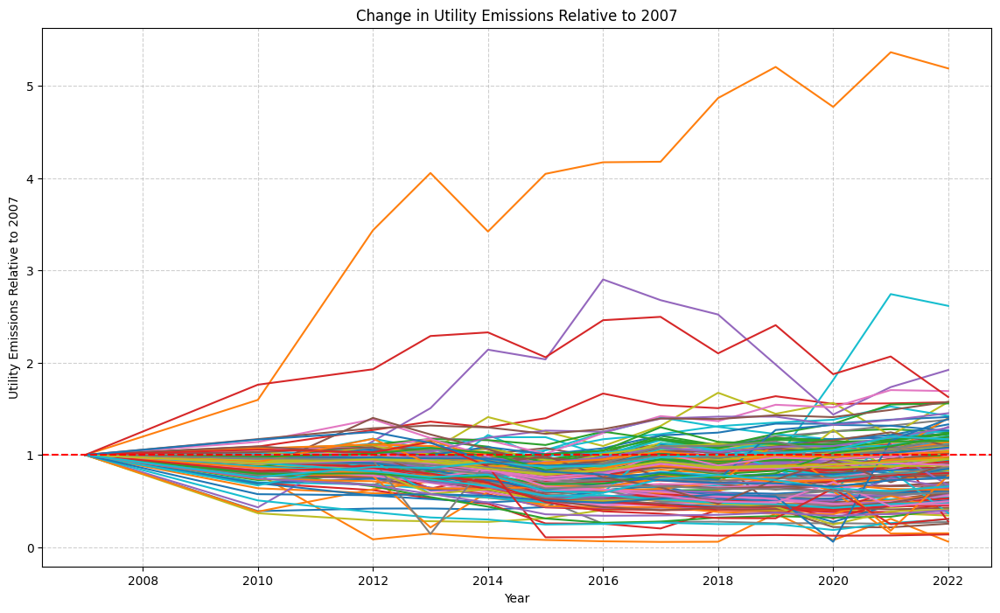

In [184]:
# Set a larger figure size for better readability
plt.figure(figsize=(14, 8))

# Transpose (.T) the DataFrame so years are on the x-axis and plot
ax = relative_utility_emissions.T.plot(figsize=(14, 8), legend=False)

# Add a horizontal line at 1.0 to clearly show the 2007 baseline
ax.axhline(y=1.0, color='red', linestyle='--', label='2007 Baseline')

# Add labels and a title to make the plot understandable
ax.set_title('Change in Utility Emissions Relative to 2007')
ax.set_xlabel('Year')
ax.set_ylabel('Utility Emissions Relative to 2007')
#ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 1400x800 with 0 Axes>

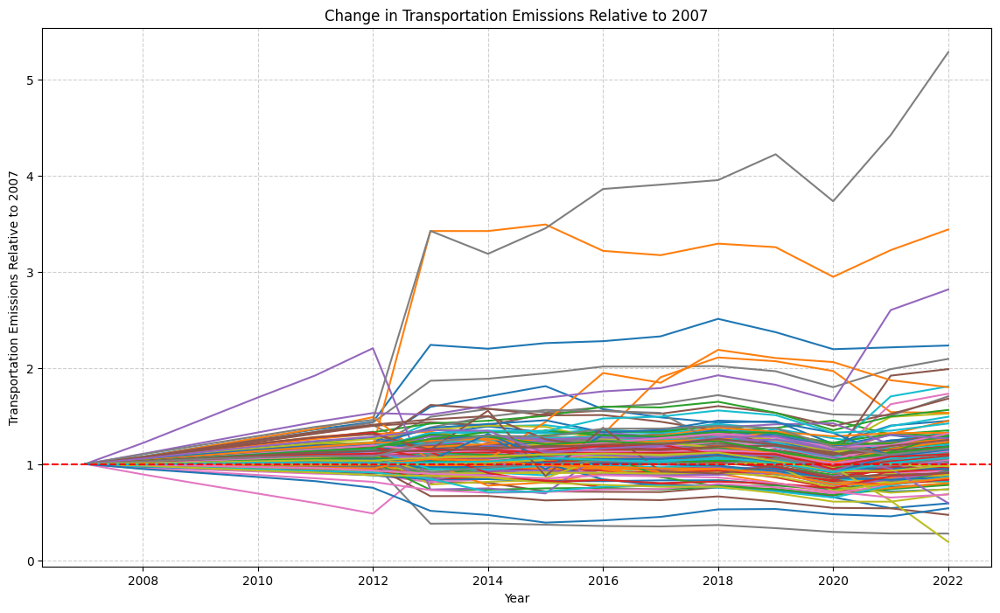

In [185]:
# Set a larger figure size for better readability
plt.figure(figsize=(14, 8))

# Transpose (.T) the DataFrame so years are on the x-axis and plot
ax = relative_transportation_emissions.T.plot(figsize=(14, 8), legend=False)

# Add a horizontal line at 1.0 to clearly show the 2007 baseline
ax.axhline(y=1.0, color='red', linestyle='--', label='2007 Baseline')

# Add labels and a title to make the plot understandable
ax.set_title('Change in Transportation Emissions Relative to 2007')
ax.set_xlabel('Year')
ax.set_ylabel('Transportation Emissions Relative to 2007')
#ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [186]:
# Define decoupling function
def categorize_decoupling(emissions_change, wellbeing_change):
    if emissions_change < -0.5 and wellbeing_change > 0.5:
        return 'em<0, wel>0'  # Best case: emissions down, wellbeing up
    elif emissions_change > 0.5 and wellbeing_change > 0.5 and wellbeing_change > emissions_change:
        return 'em>0, wel>0, wel>em'  # Good: wellbeing growing faster than emissions
    elif emissions_change < -0.5 and wellbeing_change < -0.5 and abs(wellbeing_change) < abs(emissions_change):
        return 'em<0, wel<0, abs(wel)<abs(em)'      # Emissions falling faster than wellbeing
    elif (emissions_change > 0.5 and wellbeing_change > 0.5) and wellbeing_change < emissions_change:
        return 'em>0, wel>0, wel<em'             # Moving up but emissions growing faster than wellbeing
    elif emissions_change < -0.5 and wellbeing_change < -0.5 and abs(wellbeing_change) > abs(emissions_change):
        return 'em<0, wel<0, abs(wel)>abs(em)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change < -0.5 and wellbeing_change < -0.5 and abs(emissions_change) > abs(wellbeing_change):
        return 'em<0, wel<0, abs(em)>abs(wel)' # Both down, but wellbeing falling faster than emissions
    elif emissions_change > 0.5 and wellbeing_change < -0.5:
        return 'em>0, wel<0'  # Worst case: emissions up, wellbeing down
    else:
        return 'Other'

# Apply decoupling categorization
#final_analysis_data['total_emissions_decoupling_type'] = final_analysis_data.apply(
#    lambda row: categorize_decoupling(row['Emissions_Percent_Change'], row['cwb_percent_change']), axis=1
#)

#final_analysis_data['total_emissions_per_capita_decoupling_type'] = final_analysis_data.apply(
#    lambda row: categorize_decoupling(row['total_emissions_per_capita_change'], row['cwb_percent_change']), axis=1
#)

#Repeat the decoupling categorization for transportation, utility and industrial emissions

final_analysis_data['transportation_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['transportation_emissions_percent_change'], row['cwb_percent_change']), axis=1
)

final_analysis_data['utility_emissions_decoupling_type'] = final_analysis_data.apply(
    lambda row: categorize_decoupling(row['utility_emissions_percent_change'], row['cwb_percent_change']), axis=1
)




average of two datapoints (2017 and 2020)
em<0, wel>0                      78
em>0, wel>0, wel<em              48

average of four datapoints 2017, 2018, 2019, 2020
em<0, wel>0                      82
em>0, wel>0, wel<em              43


In [187]:
# Summary statistics for transportation emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nTransportation Emissions vs Wellbeing:")
print(final_analysis_data['transportation_emissions_decoupling_type'].value_counts())

print(f"\nAverage transportation emissions change: {final_analysis_data['transportation_emissions_percent_change'].mean():.2f}%")
print(f"Average wellbeing change: {final_analysis_data['cwb_percent_change'].mean():.2f}%")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Municipality_Name', 'transportation_emissions_percent_change', 'cwb_percent_change', 'transportation_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Transportation Emissions vs Wellbeing:
transportation_emissions_decoupling_type
em>0, wel>0, wel<em              80
em<0, wel>0                      36
Other                            17
em>0, wel>0, wel>em              15
em<0, wel<0, abs(wel)<abs(em)     6
em>0, wel<0                       6
em<0, wel<0, abs(wel)>abs(em)     1
Name: count, dtype: int64

Average transportation emissions change: 9.34%
Average wellbeing change: 3.29%

=== SAMPLE OF MERGED DATA ===
  Municipality_Name  transportation_emissions_percent_change  \
0        Abbotsford                                21.885833   
1         Alert Bay                                12.767207   
2            Anmore                                14.163477   
3         Armstrong                                -1.371364   
4          Ashcroft                               -12.037116   
5          Barriere                               -28.012744   
6          Belcarra                           

In [188]:

# Summary statistics for utility emissions
print("=== DECOUPLING ANALYSIS SUMMARY ===")
print("\nUtility Emissions vs Wellbeing:")
print(final_analysis_data['utility_emissions_decoupling_type'].value_counts())

print(f"\nMean utility emissions change: {final_analysis_data['utility_emissions_percent_change'].mean():.2f}% and std: {final_analysis_data['utility_emissions_percent_change'].std():.2f}")
print(f"\nMean transportation emissions change: {final_analysis_data['transportation_emissions_percent_change'].mean():.2f}% and std: {final_analysis_data['transportation_emissions_percent_change'].std():.2f}")
print(f"\nMean population percent change: {final_analysis_data['population_percent_change'].mean():.2f}% and std: {final_analysis_data['population_percent_change'].std():.2f}")
print(f"\nMean Education percent change: {final_analysis_data['education_percent_change'].mean():.2f}% and std: {final_analysis_data['education_percent_change'].std():.2f}")
print(f"\nMean Income percent change: {final_analysis_data['income_percent_change'].mean():.2f}% and std: {final_analysis_data['income_percent_change'].std():.2f}")
print(f"\nMean Housing adequacy percent change: {final_analysis_data['housing_percent_change'].mean():.2f}% and std: {final_analysis_data['housing_percent_change'].std():.2f}")
print(f"\nMean Labour force participation percent change: {final_analysis_data['labour_percent_change'].mean():.2f}% and std: {final_analysis_data['labour_percent_change'].std():.2f}")
print(f"\nMean Wellbeing percent change: {final_analysis_data['cwb_percent_change'].mean():.2f}% and std: {final_analysis_data['cwb_percent_change'].std():.2f}")

# Preview the merged data
print("\n=== SAMPLE OF MERGED DATA ===")
print(final_analysis_data[['Municipality_Name', 'utility_emissions_percent_change', 'cwb_percent_change', 'utility_emissions_decoupling_type']].head(10))

=== DECOUPLING ANALYSIS SUMMARY ===

Utility Emissions vs Wellbeing:
utility_emissions_decoupling_type
em<0, wel>0                      82
em>0, wel>0, wel<em              43
Other                            14
em<0, wel<0, abs(wel)<abs(em)    11
em>0, wel>0, wel>em              10
em>0, wel<0                       1
Name: count, dtype: int64

Mean utility emissions change: -10.89% and std: 40.06

Mean transportation emissions change: 9.34% and std: 32.38

Mean population percent change: 10.17% and std: 25.44

Mean Education percent change: 6.50% and std: 7.42

Mean Income percent change: 7.46% and std: 5.69

Mean Housing adequacy percent change: 0.63% and std: 3.56

Mean Labour force participation percent change: 0.32% and std: 5.63

Mean Wellbeing percent change: 3.29% and std: 3.76

=== SAMPLE OF MERGED DATA ===
  Municipality_Name  utility_emissions_percent_change  cwb_percent_change  \
0        Abbotsford                         14.980045            2.564103   
1         Alert Bay

In [189]:
# Save for further analysis
final_analysis_data.to_csv(os.path.join('..','data','processed','emissions_wellbeing_decoupling_analysis.csv'), index=False)
print("\nFinal dataset saved!")


Final dataset saved!


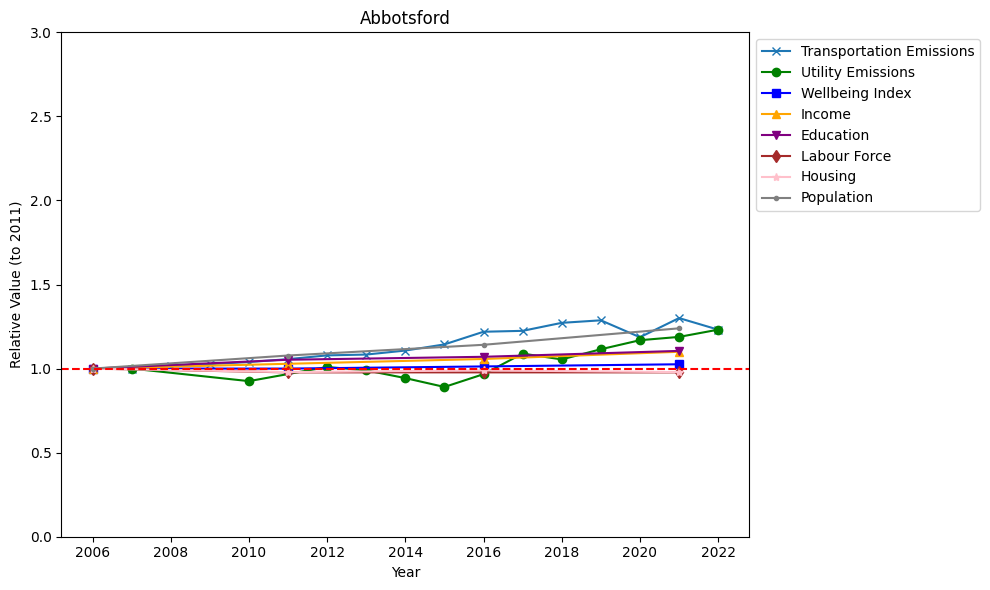

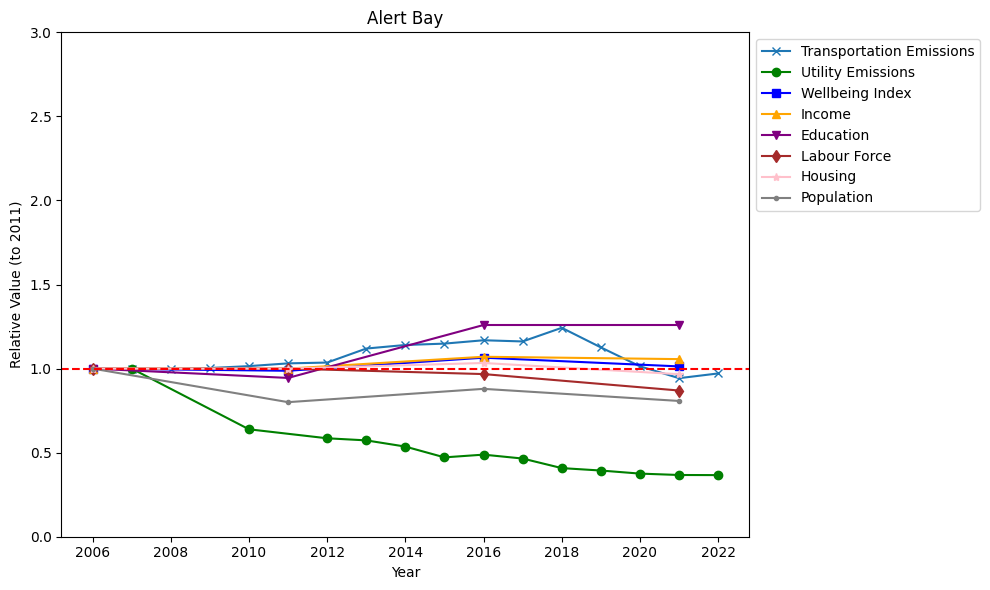

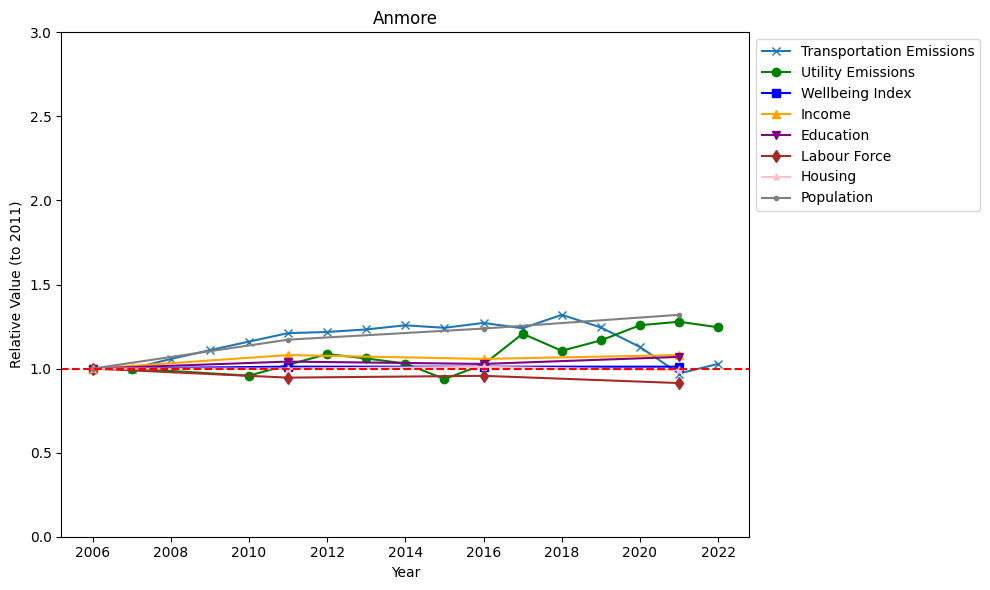

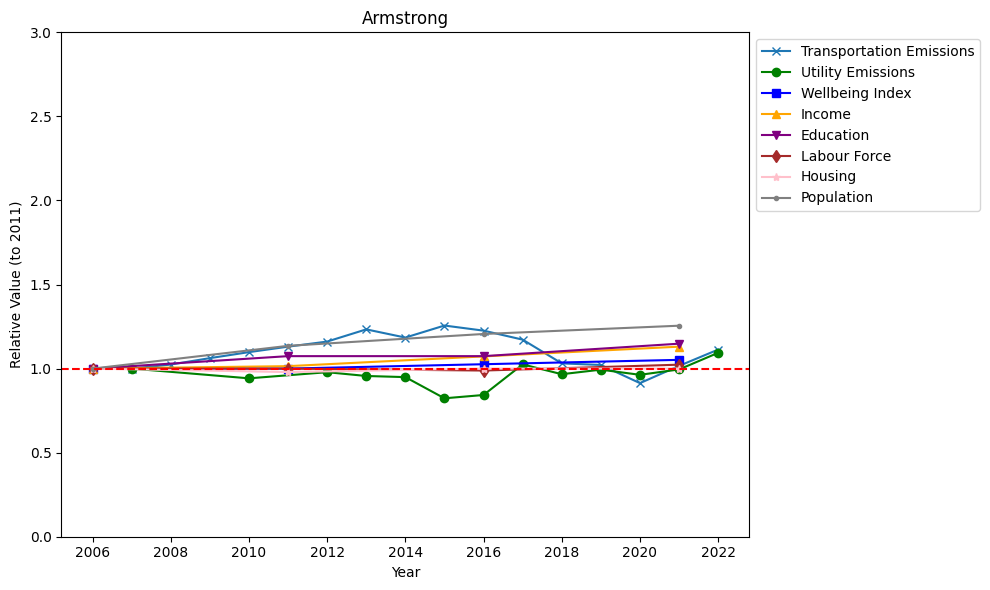

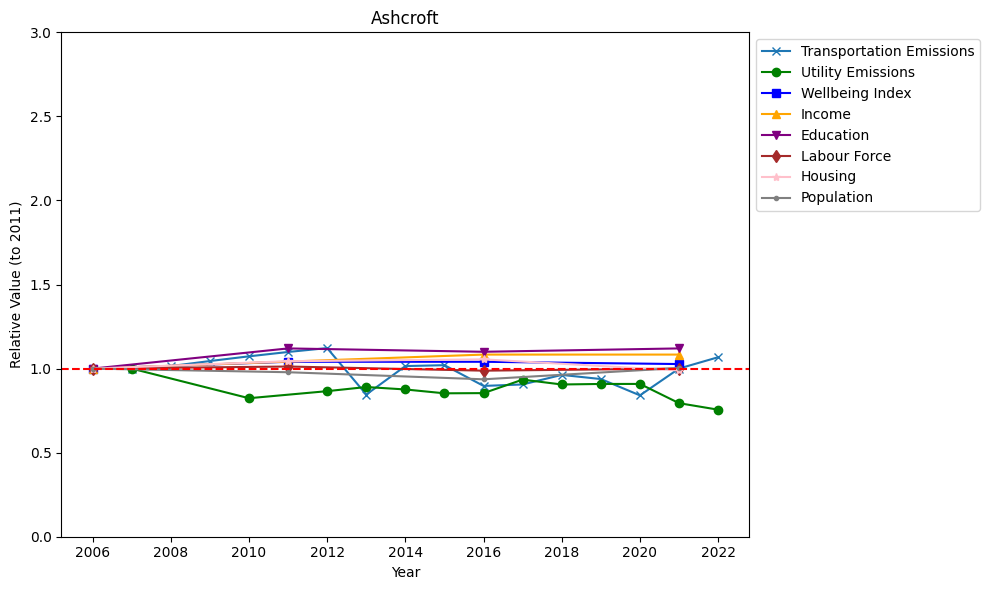

...

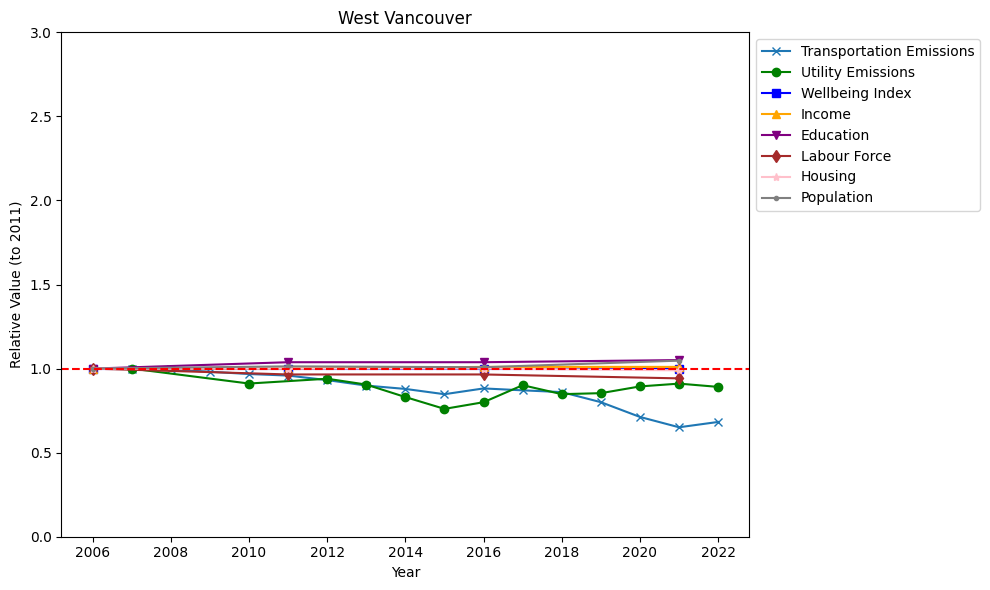

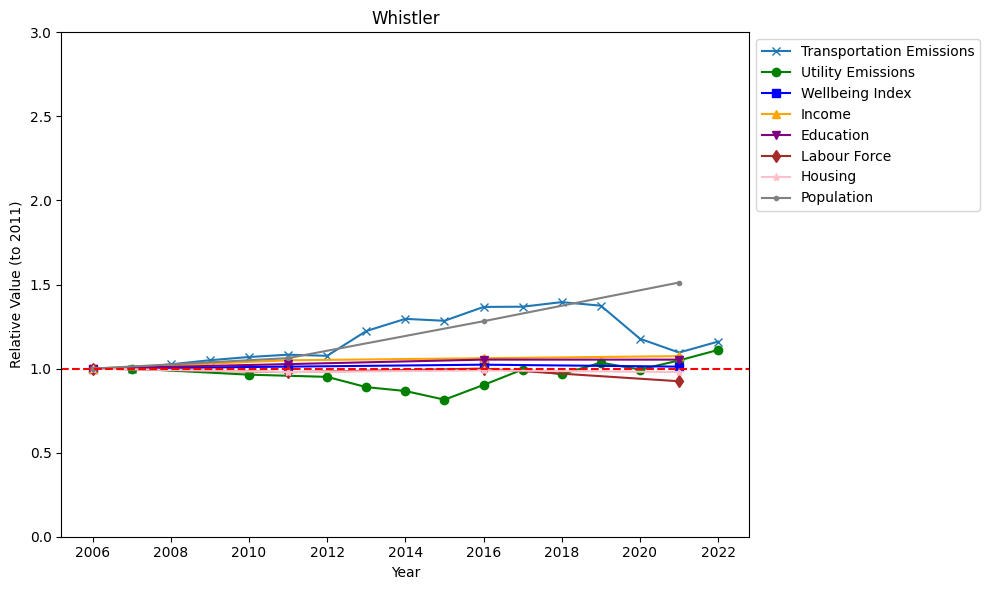

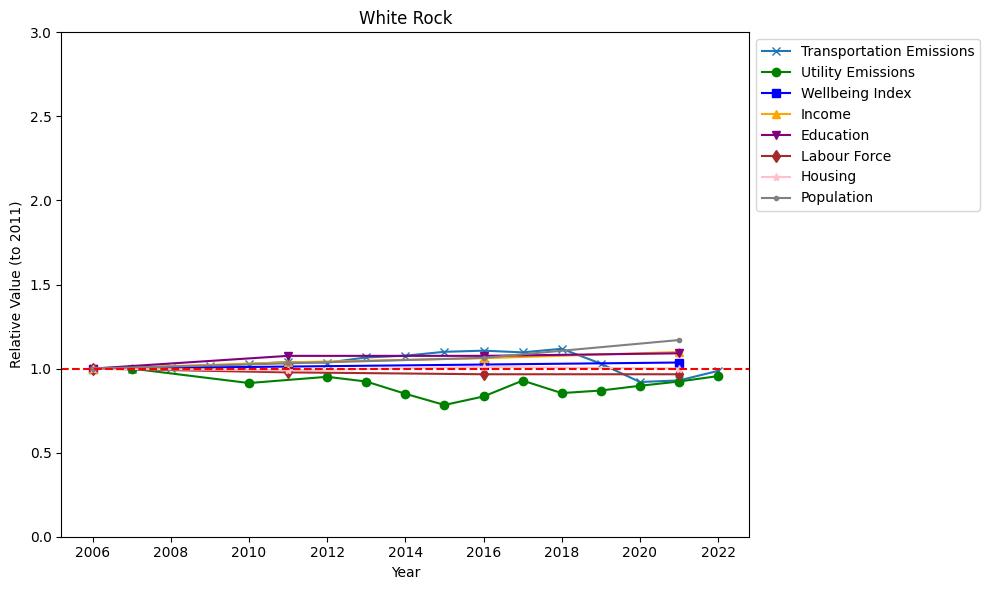

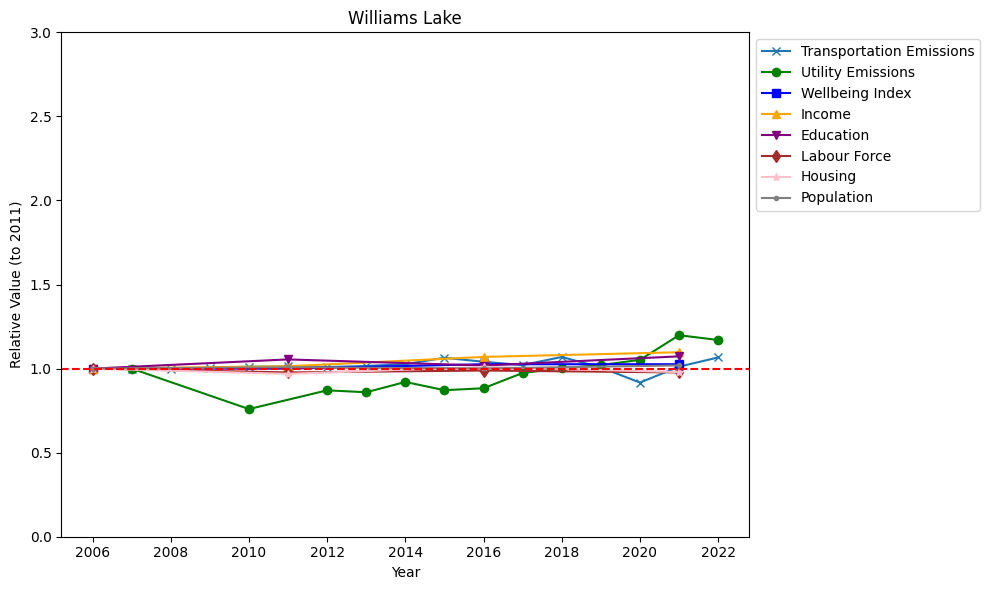

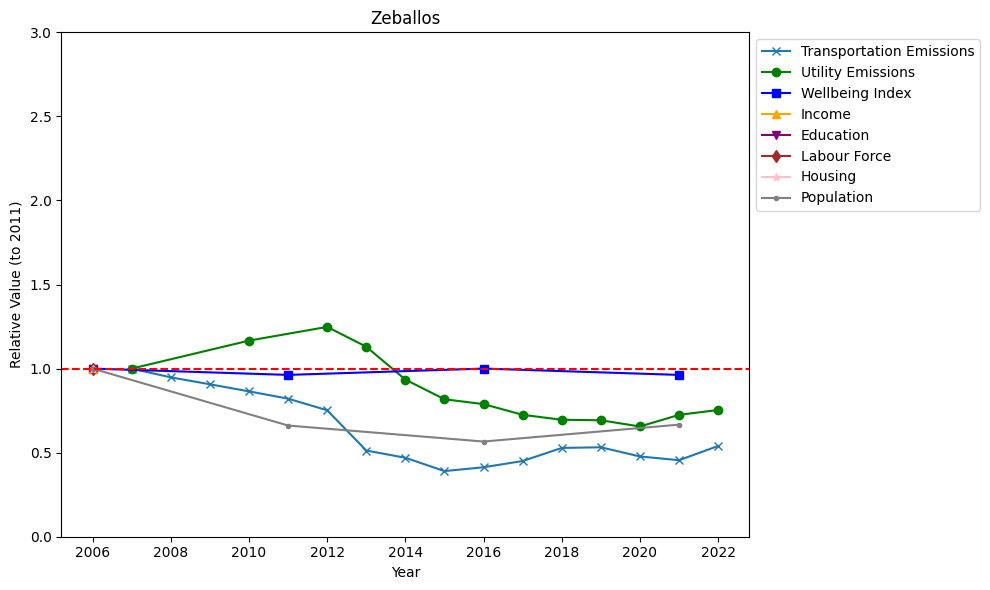

In [190]:
# Create relative values (to 2011) for each metric
wellbeing_combined_2006['CWB_rel'] = wellbeing_combined_2006['CWB 2021'] / wellbeing_combined_2006['CWB 2006']
wellbeing_combined_2006['Income_rel'] = wellbeing_combined_2006['Income 2021'] / wellbeing_combined_2006['Income 2006']
wellbeing_combined_2006['Education_rel'] = wellbeing_combined_2006['Education 2021'] / wellbeing_combined_2006['Education 2006']
wellbeing_combined_2006['Housing_rel'] = wellbeing_combined_2006['Housing 2021'] / wellbeing_combined_2006['Housing 2006']
wellbeing_combined_2006['Labour_rel'] = wellbeing_combined_2006['Labour Force Activity 2021'] / wellbeing_combined_2006['Labour Force Activity 2006']
wellbeing_combined_2006['Population_rel'] = wellbeing_combined_2006['Census Population 2021'] / wellbeing_combined_2006['Census Population 2006']

# Plot for each community
for org_name in relative_transportation_emissions.index:
    fig, ax = plt.subplots(figsize=(10,6))
    
    transportation_data = relative_transportation_emissions.loc[org_name]
    utility_data = relative_utility_emissions.loc[org_name]
    
    # Get relative wellbeing and subcategories
    rel_row = wellbeing_combined_2006[wellbeing_combined_2006['Municipality_Name'] == org_name]
    if rel_row.empty:
        continue  # skip if not found
    
    ax.plot(transportation_data.index, transportation_data.values, label='Transportation Emissions', marker='x')
    ax.plot(utility_data.index, utility_data.values, label='Utility Emissions', marker='o', color='green')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['CWB 2011'].values[0]/rel_row['CWB 2006'].values[0], rel_row['CWB 2016'].values[0]/rel_row['CWB 2006'].values[0], rel_row['CWB_rel'].values[0]], label='Wellbeing Index', marker='s', color='blue')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['Income 2011'].values[0]/rel_row['Income 2006'].values[0], rel_row['Income 2016'].values[0]/rel_row['Income 2006'].values[0], rel_row['Income_rel'].values[0]], label='Income', marker='^', color='orange')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['Education 2011'].values[0]/rel_row['Education 2006'].values[0], rel_row['Education 2016'].values[0]/rel_row['Education 2006'].values[0], rel_row['Education_rel'].values[0]], label='Education', marker='v', color='purple')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['Labour Force Activity 2011'].values[0]/rel_row['Labour Force Activity 2006'].values[0], rel_row['Labour Force Activity 2016'].values[0]/rel_row['Labour Force Activity 2006'].values[0], rel_row['Labour_rel'].values[0]], label='Labour Force', marker='d', color='brown')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['Housing 2011'].values[0]/rel_row['Housing 2006'].values[0], rel_row['Housing 2016'].values[0]/rel_row['Housing 2006'].values[0], rel_row['Housing_rel'].values[0]], label='Housing', marker='*', color='pink')
    ax.plot([2006, 2011, 2016, 2021], [1, rel_row['Census Population 2011'].values[0]/rel_row['Census Population 2006'].values[0], rel_row['Census Population 2016'].values[0]/rel_row['Census Population 2006'].values[0], rel_row['Population_rel'].values[0]], label='Population', marker='.', color='grey')
    
    ax.axhline(y=1.0, color='red', linestyle='--')
    ax.set_title(org_name)
    ax.set_xlabel('Year')
    ax.set_ylabel('Relative Value (to 2011)')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_ylim(bottom=0)
    ax.set_ylim(top=3)
    plt.tight_layout()
    plt.show()

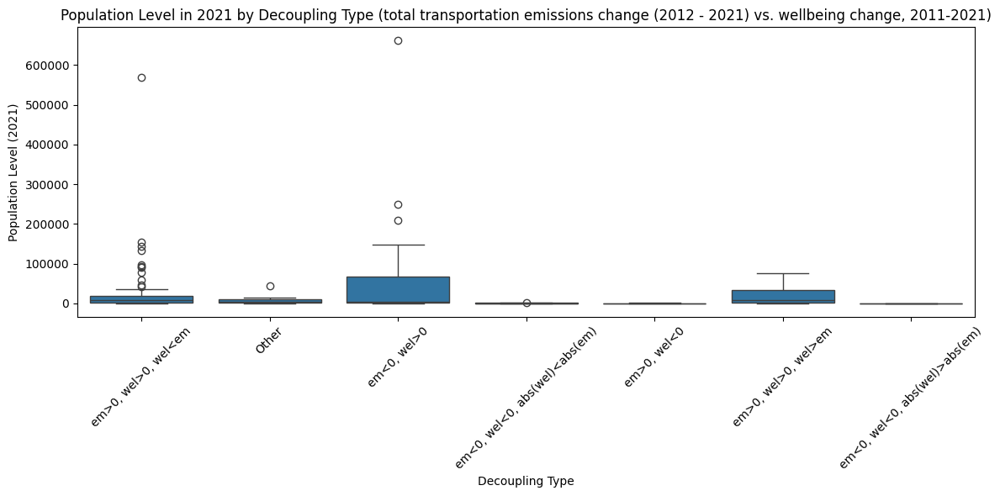

In [191]:
import seaborn as sns

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='transportation_emissions_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total transportation emissions change (2012 - 2021) vs. wellbeing change, 2011-2021)')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

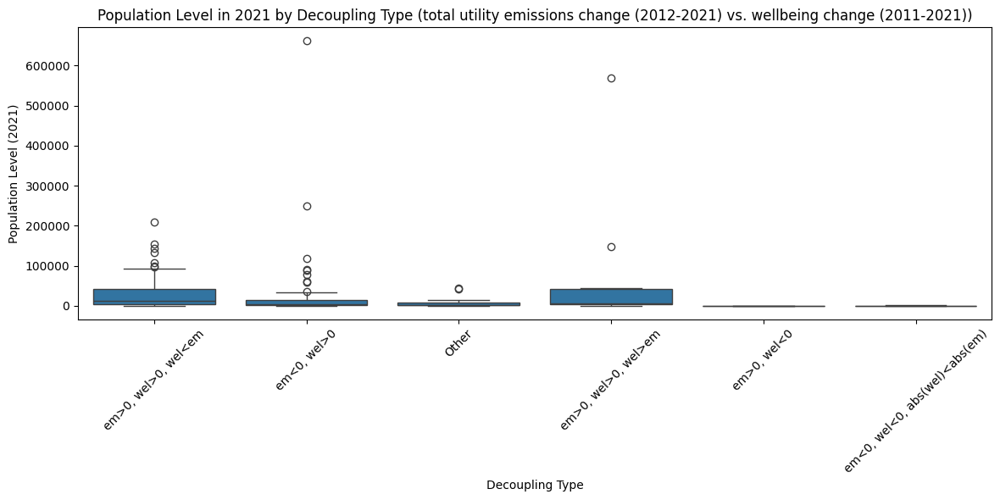

In [192]:

#plot population level in 2021 vs whether the community is decoupling or not
plt.figure(figsize=(12, 6))
sns.boxplot(x='utility_emissions_decoupling_type', y='Census Population 2021', data=final_analysis_data)
plt.title('Population Level in 2021 by Decoupling Type (total utility emissions change (2012-2021) vs. wellbeing change (2011-2021))')
plt.xlabel('Decoupling Type')
plt.ylabel('Population Level (2021)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [193]:
#get coordinates of each city in the bc-gazetteer-2024-06-13.csv file in the raw data folder
gazeteer = pd.read_csv(os.path.join('..','data','raw','bc-gazetteer-2024-06-13.csv'))
# Filter for communities in the final analysis data
gazeteer_filtered = gazeteer[gazeteer['Official Name'].isin(final_analysis_data['Municipality_Name']) & gazeteer['Feature Type'].isin(['City', 'Town', 'District Municipality', 'District Municipality (1)', 'Village (1)','Resort Municipality', 'Mountain Resort Municipality'])]


In [194]:
#print all unique official names in the gazeteer_filtered dataframe
print("Unique official names in gazeteer_filtered:")
print(gazeteer_filtered['Official Name'].unique())
#count unique official names
print(f"Total unique official names in gazeteer_filtered: {gazeteer_filtered['Official Name'].nunique()}")
#figure out which communities are missing coordinates
missing_coordinates = final_analysis_data[~final_analysis_data['Municipality_Name'].isin(gazeteer_filtered['Official Name'])]
print(f"Communities missing coordinates: {len(missing_coordinates)}")
print("Missing communities:")
for community in missing_coordinates['Municipality_Name'].unique():
    print(f"  {community}")

Unique official names in gazeteer_filtered:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission' 'Montrose' 'Nakusp'
 'Nanaimo' 'Nelson

In [195]:
# Manual mapping for missing communities using both name and feature type
name_featuretype_corrections = {
    "Langley City": ("Langley", "City"),
    "Langley Township": ("Langley", "District Municipality (1)"),
    "North Vancouver City": ("North Vancouver", "City"),
    "North Vancouver District": ("North Vancouver", "District Municipality (1)"),
    "One Hundred Mile House": ("100 Mile House", "District Municipality (1)"),
    "Sun Peaks Mountain Resort": ("Sun Peaks", "Mountain Resort Municipality"),
    "West Kelowna": ("West Kelowna, City of", "City"),
    "Queen Charlotte": ("Queen Charlotte", "Post Office"),
    "Sechelt IGD": ("Sechelt Indian Government District", "Indian Government District"),
    "Northern Rockies" :("Northern Rockies Regional Municipality","District Municipality (1)") 
}

missing_coords = []
for community, (gaz_name, feature_type) in name_featuretype_corrections.items():
    if feature_type:
        match = gazeteer[(gazeteer['Official Name'].str.lower() == gaz_name.lower()) &
                         (gazeteer['Feature Type'].str.lower() == feature_type.lower())]
    else:
        match = gazeteer[gazeteer['Official Name'].str.lower() == gaz_name.lower()]
    if not match.empty:
        feature_type = match.iloc[0]['Feature Type']
        lat = match.iloc[0]['LatDD']
        lon = match.iloc[0]['LongDD']
        datum = match.iloc[0]['Datum']
        missing_coords.append({'Official Name': community, 'Feature Type': feature_type, 'Datum': datum, 'LatDD': lat, 'LongDD': lon})
    else:
        print(f"Not found in gazeteer: {community} -> {gaz_name} ({feature_type})")

missing_coords_df = pd.DataFrame(missing_coords)
print(missing_coords_df)

               Official Name                  Feature Type  Datum      LatDD  \
0               Langley City                          City  WGS84  49.102500   
1           Langley Township     District Municipality (1)  WGS84  49.120278   
2       North Vancouver City                          City  WGS84  49.320556   
3   North Vancouver District     District Municipality (1)  WGS84  49.336111   
4     One Hundred Mile House     District Municipality (1)  WGS84  51.642778   
5  Sun Peaks Mountain Resort  Mountain Resort Municipality  WGS84  50.884444   
6               West Kelowna                          City  WGS84  49.830000   
7            Queen Charlotte                   Post Office  WGS84  53.253878   
8                Sechelt IGD    Indian Government District  WGS84  49.478960   
9           Northern Rockies     District Municipality (1)  WGS84  58.803889   

       LongDD  
0 -122.658056  
1 -122.659722  
2 -123.073889  
3 -123.078056  
4 -121.295556  
5 -119.879444  
6 -119.

In [196]:
#add missing communities to gazeteer_filtered
gazeteer_filtered = pd.concat([gazeteer_filtered, missing_coords_df]).reset_index(drop=True)
gazeteer_filtered.head()
#gazeteer_filtered.tail(20)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
0,Abbotsford,City,1.0,92G/1,49 03 07 N,122 19 45 W,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),3.0,92L/10,50 35 01 N,126 55 40 W,WGS84,50.583889,-126.927778
2,Anmore,Village (1),3.0,92G/7,49 18 51 N,122 51 23 W,WGS84,49.314444,-122.856389
3,Armstrong,City,1.0,82L/6,50 26 53 N,119 11 48 W,WGS84,50.448333,-119.196667
4,Ashcroft,Village (1),3.0,92I/11,50 43 16 N,121 17 00 W,WGS84,50.721389,-121.283611


In [197]:
gazeteer_filtered.tail(2)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
159,Sechelt IGD,Indian Government District,NaN,NaN,NaN,NaN,WGS84,49.478960,-123.742985
160,Northern Rockies,District Municipality (1),NaN,NaN,NaN,NaN,WGS84,58.803889,-122.706667


In [198]:
#check if the gazeteer_filtered dataframe has all the communities from final_analysis_data
print(f"Total communities in final_analysis_data: {len(final_analysis_data['Municipality_Name'].unique())}")
print(f"Total communities in gazeteer_filtered: {len(gazeteer_filtered['Official Name'].unique())}")
missing_communities =  set(gazeteer_filtered['Official Name'].unique()) - set(final_analysis_data['Municipality_Name'].unique())
print(f"Missing communities in gazeteer_filtered: {len(missing_communities)}")
if missing_communities:
    print("Missing communities:")
    for community in missing_communities:
        print(f"  {community}")

Total communities in final_analysis_data: 161
Total communities in gazeteer_filtered: 161
Missing communities in gazeteer_filtered: 0


In [199]:
#find duplicates
duplicates = gazeteer_filtered[gazeteer_filtered.duplicated(subset=['Official Name'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
if not duplicates.empty:
    print("Duplicate entries:")
    for index, row in duplicates.iterrows():
        print(f"  {row['Official Name']} (Index: {index})")


Total duplicates found: 0


In [200]:
#extract official name, feature type, datum, latitude and longitude from gazeteer_filtered
gazeteer_final = gazeteer_filtered[['Official Name', 'Feature Type', 'Datum', 'LatDD', 'LongDD']].copy()
gazeteer_final.rename(columns={
    'Official Name': 'Municipality_Name',
    'Feature Type': 'Feature_Type',
    'Datum': 'Datum',
    'LatDD': 'Latitude',
    'LongDD': 'Longitude'
}, inplace=True)
# Save the gazeteer_final dataframe to a CSV file in the processed data folder
gazeteer_final.to_csv(os.path.join('..', 'data', 'processed', 'gazeteer_final.csv'), index=False)

In [201]:
gazeteer_final.head(2)

,Municipality_Name,Feature_Type,Datum,Latitude,Longitude
0,Abbotsford,City,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),WGS84,50.583889,-126.927778


In [202]:
#merge the gazeteer data with the final_analysis_data
final_analysis_data_with_coords = pd.merge(final_analysis_data, gazeteer_final, on='Municipality_Name')
# Save the final analysis data with coordinates to a CSV file in the processed data folder
final_analysis_data_with_coords.to_csv(os.path.join('..', 'data', 'processed', 'final_analysis_data_with_coords.csv'), index=False)
# Display the final analysis data with coordinates
print("Final analysis data with coordinates:")
print(final_analysis_data_with_coords.head())

Final analysis data with coordinates:
  Municipality_Name  avg_transportation_emissions_2007_2010  \
0        Abbotsford                           476017.792959   
1         Alert Bay                             1029.893462   
2            Anmore                             6304.853183   
3         Armstrong                            22954.802496   
4          Ashcroft                             7792.336643   

   avg_transportation_emissions_2017_2020  \
0                           580198.250399   
1                             1161.382094   
2                             7197.839592   
3                            22640.008639   
4                             6854.364010   

   transportation_emissions_percent_change  avg_utility_emissions_2007_2010  \
0                                21.885833                    355367.557275   
1                                12.767207                       684.670685   
2                                14.163477                      4348.679366

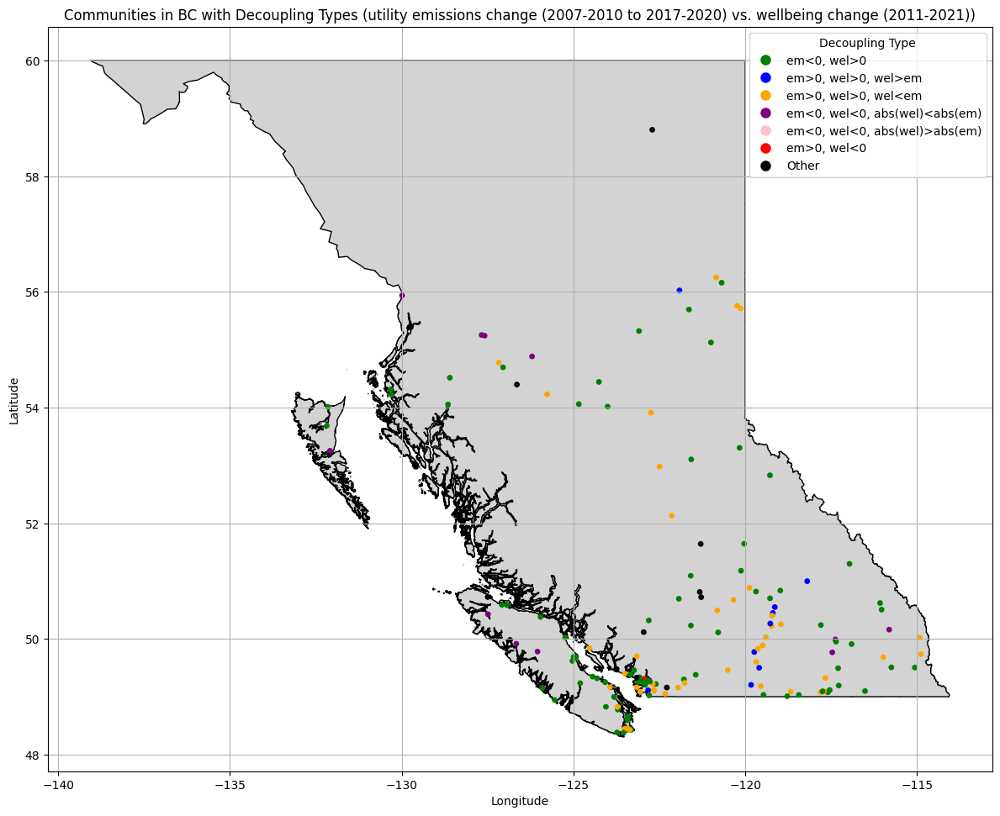

In [203]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}


final_analysis_gdf['color'] = final_analysis_gdf['utility_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (utility emissions change (2007-2010 to 2017-2020) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

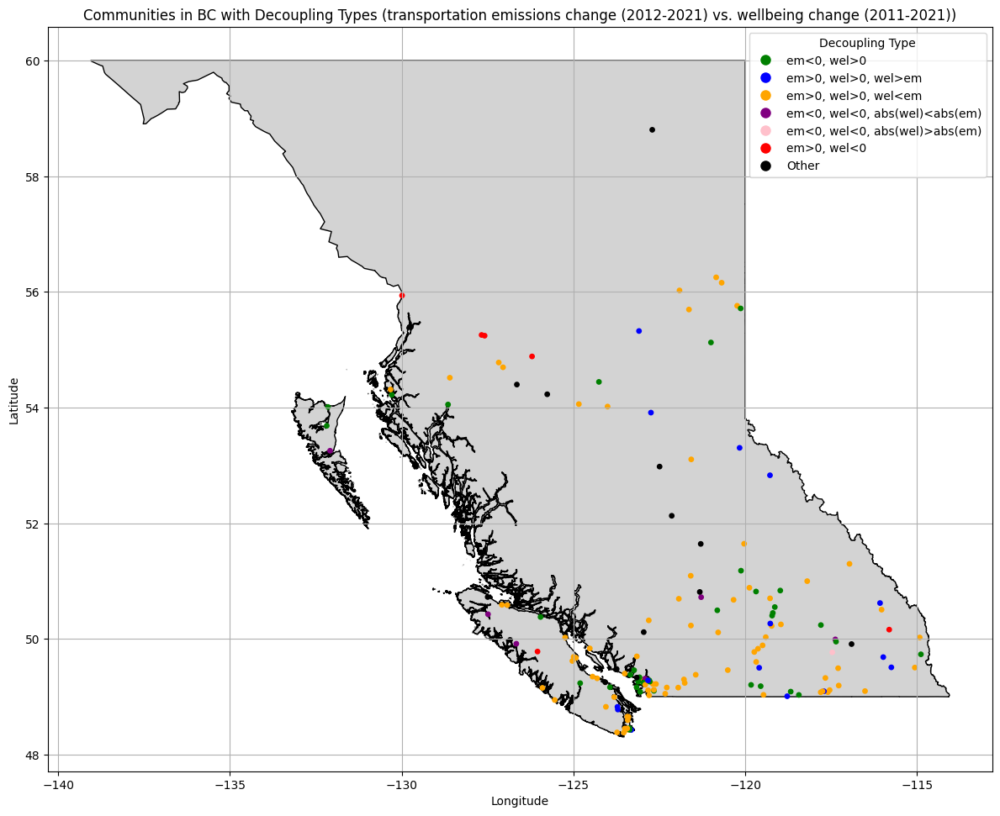

In [204]:
final_analysis_gdf['color'] = final_analysis_gdf['transportation_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (transportation emissions change (2012-2021) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [205]:
# Find name of communities in the worse case scenario of transportation emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['transportation_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['transportation_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


12      Canal Flats
40       Gold River
43         Granisle
46         Hazelton
84     New Hazelton
135         Stewart
Name: Municipality_Name, dtype: object 12     29.087871
40     23.069154
43     11.529057
46     26.181138
84     34.634794
135     2.424826
Name: transportation_emissions_percent_change, dtype: float64 12    -2.531646
40    -2.500000
43    -1.408451
46    -2.298851
84    -1.333333
135   -1.265823
Name: cwb_percent_change, dtype: float64 12      715.0
40     1267.0
43      303.0
46      270.0
84      666.0
135     494.0
Name: Census Population 2011, dtype: float64


In [206]:
# Find name of communities in the worse case scenario of utility emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['utility_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['utility_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


6    Belcarra
Name: Municipality_Name, dtype: object 6    1.283684
Name: utility_emissions_percent_change, dtype: float64 6   -1.098901
Name: cwb_percent_change, dtype: float64 6    644.0
Name: Census Population 2011, dtype: float64


Next steps:
1) Manually create municipal shapefile boundaries for the municipalities that are missing from the data
2) Find if there is a way to include Northern Rockies
3) decide to include seachelt IDG or exclude it
4) add emissions of facilities outside of municipal boundaries to nearest municipality 




1) (DONE) map the coupling vs decoupling of municipalities across BC
    a) (DONE) find coordinates of each municipality
2) (DONE) add transportation emissions to building emissions and redo analysis
    a) show road networks in the map and power line networks as well
3) segregate analysis by sector (industry vs residential)
4) try using emissions from 2007 with wellbeing from 2006?
5) compare the disaggregated components of the wellbeing index (e.g. income vs. education vs. housing) with the emissions 
6) compare coupling/decoupling with climate action plans in LGCAP and with climate impacts to see which communities are most vulnerable
7) use actual census data (e.g. mean income value for community, education level) and make a random forest model that predicts coupling/decoupling using the census data?
8) see if the poorest communities that had lowest wellbeing to start with are the ones going through negative decoupling
9) subtract wellbeing change from emissions change to have a number that measures the extent of decoupling, or use taipa equation


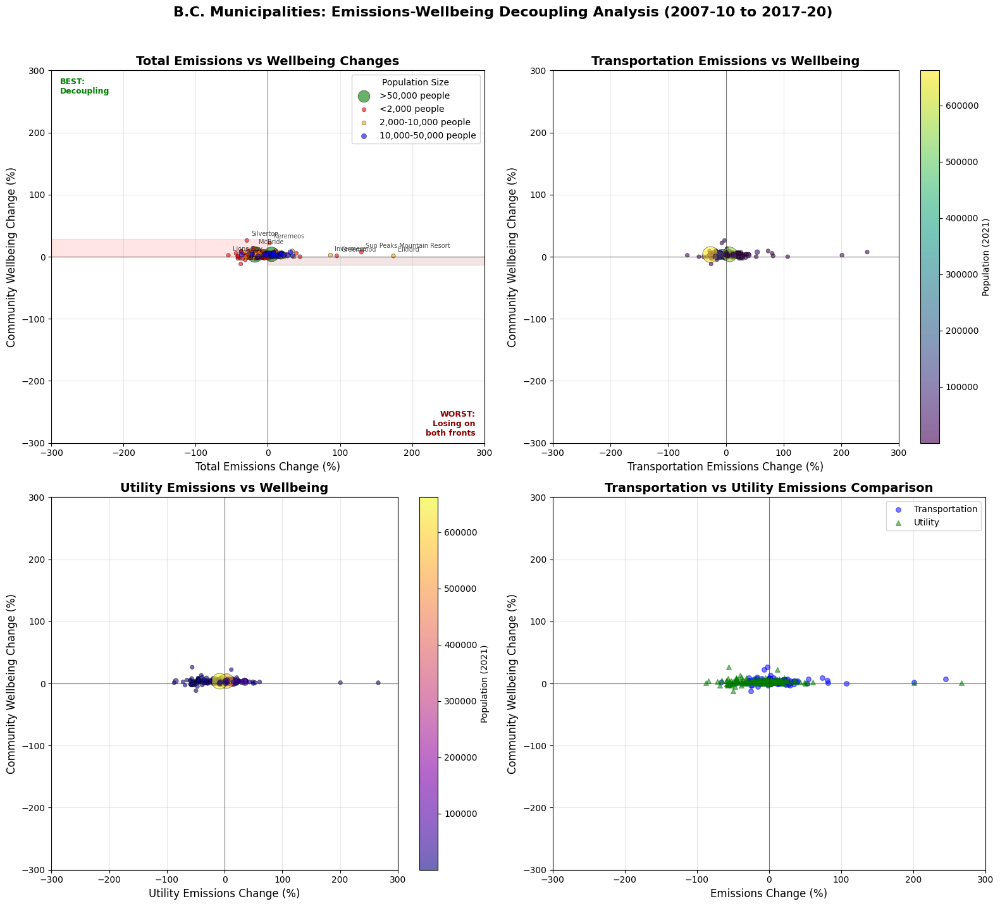


DECOUPLING ANALYSIS SUMMARY

Total municipalities analyzed: 161

Quadrant                            Count Percentage
--------------------------------------------------
Strong Decoupling (↓E, ↑W)             72      44.7%
Growth Coupled (↑E, ↑W)                64      39.8%
Decline Coupled (↓E, ↓W)               13       8.1%
Worst Case (↑E, ↓W)                     0       0.0%

--------------------------------------------------
EMISSIONS CHANGE STATISTICS
--------------------------------------------------

Metric                          Mean     Median    Std Dev
--------------------------------------------------
Total Emissions                 -0.8%       -1.9%       27.5%
Transportation                   9.3%        5.9%       32.4%
Utility                        -10.9%       -7.8%       40.1%
Wellbeing (CWB)                  3.3%        2.7%        3.8%

--------------------------------------------------
CORRELATION ANALYSIS
--------------------------------------------------
Tota

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_83041/2605731328.py:228: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strong_decoupling['decoupling_score'] = strong_decoupling['cwb_percent_change'] - strong_decoupling['total_emissions_percent_change']


In [207]:

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Calculate total emissions change (you might want to weight this differently)
# Option 1: Simple average
final_analysis_data['total_emissions_percent_change'] = (
    final_analysis_data['transportation_emissions_percent_change'] + 
    final_analysis_data['utility_emissions_percent_change']
) / 2

# Create population size categories for coloring
final_analysis_data['pop_category'] = pd.cut(
    final_analysis_data['Census Population 2021'],
    bins=[0, 2000, 10000, 50000, float('inf')],
    labels=['<2,000', '2,000-10,000', '10,000-50,000', '>50,000']
)

# Color map for population categories
colors = {'<2,000': 'red', '2,000-10,000': 'orange', '10,000-50,000': 'blue', '>50,000': 'green'}

# Normalize population for point sizes
pop_sizes = (final_analysis_data['Census Population 2021'] / final_analysis_data['Census Population 2021'].max()) * 300 + 20

# ========== PLOT 1: Total Emissions vs CWB ==========
ax1 = axes[0, 0]

for category in final_analysis_data['pop_category'].unique():
    if pd.notna(category):
        mask = final_analysis_data['pop_category'] == category
        ax1.scatter(
            final_analysis_data.loc[mask, 'total_emissions_percent_change'],
            final_analysis_data.loc[mask, 'cwb_percent_change'],
            s=pop_sizes[mask],
            alpha=0.6,
            c=colors[category],
            label=f'{category} people',
            edgecolors='black',
            linewidth=0.5
        )

# Add quadrant lines
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Add shaded quadrants
ax1.axhspan(0, ax1.get_ylim()[1], xmin=0, xmax=0.5, alpha=0.1, color='red')  # top left - best case
ax1.axhspan(ax1.get_ylim()[0], 0, xmin=0.5, xmax=1, alpha=0.1, color='darkred')  # bottom right - worst case

# Label outliers
threshold_emissions = 50  # Adjust based on your data
threshold_wellbeing = 10
for idx, row in final_analysis_data.iterrows():
    if abs(row['total_emissions_percent_change']) > threshold_emissions or abs(row['cwb_percent_change']) > threshold_wellbeing:
        ax1.annotate(
            row['Municipality_Name'], 
            (row['total_emissions_percent_change'], row['cwb_percent_change']),
            fontsize=7, 
            alpha=0.7,
            xytext=(5, 5),
            textcoords='offset points'
        )

ax1.set_xlabel('Total Emissions Change (%)', fontsize=12)
ax1.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax1.set_title('Total Emissions vs Wellbeing Changes', fontsize=14, fontweight='bold')
ax1.legend(title='Population Size', loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-300, 300)
ax1.set_ylim(-300, 300)

# Add quadrant labels
ax1.text(0.02, 0.98, 'BEST:\nDecoupling', transform=ax1.transAxes, fontsize=9, 
         verticalalignment='top', fontweight='bold', color='green')
ax1.text(0.98, 0.02, 'WORST:\nLosing on\nboth fronts', transform=ax1.transAxes, 
         fontsize=9, ha='right', fontweight='bold', color='darkred')

# ========== PLOT 2: Transportation vs CWB ==========
ax2 = axes[0, 1]

scatter2 = ax2.scatter(
    final_analysis_data['transportation_emissions_percent_change'],
    final_analysis_data['cwb_percent_change'],
    s=pop_sizes,
    c=final_analysis_data['Census Population 2021'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax2.set_xlabel('Transportation Emissions Change (%)', fontsize=12)
ax2.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax2.set_title('Transportation Emissions vs Wellbeing', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-300, 300)
ax2.set_ylim(-300, 300)

# Add colorbar for population
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Population (2021)', fontsize=10)

# ========== PLOT 3: Utility vs CWB ==========
ax3 = axes[1, 0]

scatter3 = ax3.scatter(
    final_analysis_data['utility_emissions_percent_change'],
    final_analysis_data['cwb_percent_change'],
    s=pop_sizes,
    c=final_analysis_data['Census Population 2021'],
    cmap='plasma',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax3.set_xlabel('Utility Emissions Change (%)', fontsize=12)
ax3.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax3.set_title('Utility Emissions vs Wellbeing', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-300, 300)
ax3.set_ylim(-300, 300)

# Add colorbar
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('Population (2021)', fontsize=10)

# ========== PLOT 4: Comparison Plot ==========
ax4 = axes[1, 1]

# Plot both types on same axes with different markers
ax4.scatter(final_analysis_data['transportation_emissions_percent_change'], 
           final_analysis_data['cwb_percent_change'],
           s=30, alpha=0.5, c='blue', label='Transportation', marker='o')
ax4.scatter(final_analysis_data['utility_emissions_percent_change'], 
           final_analysis_data['cwb_percent_change'],
           s=30, alpha=0.5, c='green', label='Utility', marker='^')

ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax4.set_xlabel('Emissions Change (%)', fontsize=12)
ax4.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax4.set_title('Transportation vs Utility Emissions Comparison', fontsize=14, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(-300, 300)
ax4.set_ylim(-300, 300)

plt.suptitle('B.C. Municipalities: Emissions-Wellbeing Decoupling Analysis (2007-10 to 2017-20)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== PRINT ANALYSIS ==========
print("\n" + "="*60)
print("DECOUPLING ANALYSIS SUMMARY")
print("="*60)

# Remove NaN values for analysis
clean_data = final_analysis_data.dropna(subset=['total_emissions_percent_change', 'cwb_percent_change'])
print(f"\nTotal municipalities analyzed: {len(clean_data)}")

# Calculate quadrants
strong_decoupling = clean_data[(clean_data['total_emissions_percent_change'] < 0) & 
                               (clean_data['cwb_percent_change'] > 0)]
growth_coupled = clean_data[(clean_data['total_emissions_percent_change'] > 0) & 
                           (clean_data['cwb_percent_change'] > 0)]
decline_coupled = clean_data[(clean_data['total_emissions_percent_change'] < 0) & 
                            (clean_data['cwb_percent_change'] < 0)]
worst_case = clean_data[(clean_data['total_emissions_percent_change'] > 0) & 
                       (clean_data['cwb_percent_change'] < 0)]

print(f"\n{'Quadrant':<30} {'Count':>10} {'Percentage':>10}")
print("-"*50)
print(f"{'Strong Decoupling (↓E, ↑W)':<30} {len(strong_decoupling):>10} {len(strong_decoupling)/len(clean_data)*100:>9.1f}%")
print(f"{'Growth Coupled (↑E, ↑W)':<30} {len(growth_coupled):>10} {len(growth_coupled)/len(clean_data)*100:>9.1f}%")
print(f"{'Decline Coupled (↓E, ↓W)':<30} {len(decline_coupled):>10} {len(decline_coupled)/len(clean_data)*100:>9.1f}%")
print(f"{'Worst Case (↑E, ↓W)':<30} {len(worst_case):>10} {len(worst_case)/len(clean_data)*100:>9.1f}%")

# Statistics by emissions type
print("\n" + "-"*50)
print("EMISSIONS CHANGE STATISTICS")
print("-"*50)
print(f"\n{'Metric':<25} {'Mean':>10} {'Median':>10} {'Std Dev':>10}")
print("-"*50)
print(f"{'Total Emissions':<25} {clean_data['total_emissions_percent_change'].mean():>10.1f}% {clean_data['total_emissions_percent_change'].median():>10.1f}% {clean_data['total_emissions_percent_change'].std():>10.1f}%")
print(f"{'Transportation':<25} {clean_data['transportation_emissions_percent_change'].mean():>10.1f}% {clean_data['transportation_emissions_percent_change'].median():>10.1f}% {clean_data['transportation_emissions_percent_change'].std():>10.1f}%")
print(f"{'Utility':<25} {clean_data['utility_emissions_percent_change'].mean():>10.1f}% {clean_data['utility_emissions_percent_change'].median():>10.1f}% {clean_data['utility_emissions_percent_change'].std():>10.1f}%")
print(f"{'Wellbeing (CWB)':<25} {clean_data['cwb_percent_change'].mean():>10.1f}% {clean_data['cwb_percent_change'].median():>10.1f}% {clean_data['cwb_percent_change'].std():>10.1f}%")

# Correlation analysis
print("\n" + "-"*50)
print("CORRELATION ANALYSIS")
print("-"*50)
corr_total = clean_data['total_emissions_percent_change'].corr(clean_data['cwb_percent_change'])
corr_transport = clean_data['transportation_emissions_percent_change'].corr(clean_data['cwb_percent_change'])
corr_utility = clean_data['utility_emissions_percent_change'].corr(clean_data['cwb_percent_change'])

print(f"Total Emissions vs Wellbeing:         {corr_total:.3f}")
print(f"Transportation Emissions vs Wellbeing: {corr_transport:.3f}")
print(f"Utility Emissions vs Wellbeing:        {corr_utility:.3f}")

# Worst performers detail
if len(worst_case) > 0:
    print("\n" + "-"*50)
    print("MUNICIPALITIES IN WORST CASE QUADRANT")
    print("-"*50)
    worst_sorted = worst_case.sort_values('cwb_percent_change')
    for _, row in worst_sorted.iterrows():
        print(f"\n{row['Municipality_Name']}:")
        print(f"  Population: {row['Census Population 2021']:,.0f}")
        print(f"  Wellbeing Change: {row['cwb_percent_change']:.1f}%")
        print(f"  Total Emissions Change: {row['total_emissions_percent_change']:.1f}%")
        print(f"  (Transport: {row['transportation_emissions_percent_change']:.1f}%, Utility: {row['utility_emissions_percent_change']:.1f}%)")

# Best performers
if len(strong_decoupling) > 0:
    print("\n" + "-"*50)
    print("TOP 5 STRONG DECOUPLING MUNICIPALITIES")
    print("-"*50)
    # Sort by combination of wellbeing increase and emissions decrease
    strong_decoupling['decoupling_score'] = strong_decoupling['cwb_percent_change'] - strong_decoupling['total_emissions_percent_change']
    best_sorted = strong_decoupling.nlargest(5, 'decoupling_score')
    for _, row in best_sorted.iterrows():
        print(f"\n{row['Municipality_Name']}:")
        print(f"  Population: {row['Census Population 2021']:,.0f}")
        print(f"  Wellbeing Change: {row['cwb_percent_change']:.1f}%")
        print(f"  Total Emissions Change: {row['total_emissions_percent_change']:.1f}%")